# Smooth Training Summary Report

This notebook summarizes the new smooth-training experiment variants. These runs add lower learning rates, `ReduceLROnPlateau`, gradient clipping, gentler augmentation, and weighted sampling support.


## 1. Smooth Training Changes

- Added `augmentation_profile: gentle` with resize, smaller rotation, and lighter color jitter.
- Added `use_weighted_sampler` to train with inverse-frequency sample weights.
- Added `use_class_weights` so weighted sampling can be used without also multiplying the loss.
- Added gradient clipping through `training.grad_clip_norm`.
- Added `ReduceLROnPlateau` scheduler support through `training.scheduler`.
- New configs live in `configs/*_smooth*.yaml`.


## 2. New Results

| Stage | Smooth run | Epochs | Val acc | Test acc | Original test acc | Test delta |
|---|---|---:|---:|---:|---:|---:|
| Stage A CNN weighted sampler | `a_custom_cnn_smooth` | 36 | 0.8176 | 0.7500 | 0.7837 | -0.0337 |
| Stage A CNN no sampler | `a_custom_cnn_smooth_no_sampler` | 40 | 0.8090 | 0.7692 | 0.7837 | -0.0144 |
| Stage B1 Frozen EfficientNet | `b1_frozen_efficientnet_smooth` | 16 | 0.7603 | 0.7917 | 0.7869 | +0.0048 |
| Stage B2 Fine-tuned EfficientNet | `b2_finetuned_efficientnet_smooth` | 25 | 0.7431 | 0.8189 | 0.8349 | -0.0160 |
| Stage C Patch LSTM 32 | `c2_patch_lstm_32_smooth` | 26 | 0.7746 | 0.7147 | 0.7548 | -0.0401 |


## 3. Smoothness Diagnostics

| Stage | Original mean val-loss jump | Smooth mean val-loss jump | Original mean val-acc jump | Smooth mean val-acc jump |
|---|---:|---:|---:|---:|
| Stage A CNN weighted sampler | 0.1282 | 0.2201 | 0.0874 | 0.0633 |
| Stage A CNN no sampler | 0.1282 | 0.1804 | 0.0874 | 0.0604 |
| Stage B1 Frozen EfficientNet | 0.0614 | 0.0217 | 0.0238 | 0.0132 |
| Stage B2 Fine-tuned EfficientNet | 0.0248 | 0.0201 | 0.0161 | 0.0142 |
| Stage C Patch LSTM 32 | 0.0470 | 0.0516 | 0.0349 | 0.0318 |


In [1]:
from pathlib import Path
import json
import statistics

RUN_PAIRS = [
    ("a_custom_cnn", "a_custom_cnn_smooth", "Stage A CNN weighted sampler"),
    ("a_custom_cnn", "a_custom_cnn_smooth_no_sampler", "Stage A CNN no sampler"),
    ("b1_frozen_efficientnet", "b1_frozen_efficientnet_smooth", "Stage B1 Frozen EfficientNet"),
    ("b2_finetuned_efficientnet", "b2_finetuned_efficientnet_smooth", "Stage B2 Fine-tuned EfficientNet"),
    ("c2_patch_lstm_32", "c2_patch_lstm_32_smooth", "Stage C Patch LSTM 32"),
]

RUN_DIR = Path("outputs/runs")
if not RUN_DIR.exists():
    RUN_DIR = Path("..") / "outputs" / "runs"

def load_metrics(run):
    return json.loads((RUN_DIR / run / "metrics.json").read_text())

def mean_jump(values):
    jumps = [abs(b - a) for a, b in zip(values, values[1:])]
    return statistics.mean(jumps) if jumps else 0.0

rows = []
for original, smooth, label in RUN_PAIRS:
    original_metrics = load_metrics(original)
    smooth_metrics = load_metrics(smooth)
    rows.append({
        "stage": label,
        "smooth_run": smooth,
        "epochs": len(smooth_metrics["history"]["val_loss"]),
        "val_acc": smooth_metrics["validation"]["accuracy"],
        "test_acc": smooth_metrics["test"]["accuracy"],
        "original_test_acc": original_metrics["test"]["accuracy"],
        "original_val_loss_jump": mean_jump(original_metrics["history"]["val_loss"]),
        "smooth_val_loss_jump": mean_jump(smooth_metrics["history"]["val_loss"]),
    })

rows


[
  {
    "stage": "Stage A CNN weighted sampler",
    "original_run": "a_custom_cnn",
    "smooth_run": "a_custom_cnn_smooth",
    "orig_epochs": 34,
    "smooth_epochs": 36,
    "orig_val_acc": 0.7679083094555874,
    "smooth_val_acc": 0.8175740210124164,
    "orig_test_acc": 0.7836538461538461,
    "smooth_test_acc": 0.75,
    "orig_val_loss_jump": 0.12820891014646577,
    "smooth_val_loss_jump": 0.22014136024379585,
    "orig_val_acc_jump": 0.08740702150444271,
    "smooth_val_acc_jump": 0.06331013780870515,
    "smooth_max_val_loss_jump": 1.3907571457176973,
    "smooth_max_val_acc_jump": 0.25405921680993315
  },
  {
    "stage": "Stage A CNN no sampler",
    "original_run": "a_custom_cnn",
    "smooth_run": "a_custom_cnn_smooth_no_sampler",
    "orig_epochs": 34,
    "smooth_epochs": 40,
    "orig_val_acc": 0.7679083094555874,
    "smooth_val_acc": 0.8089780324737345,
    "orig_test_acc": 0.7836538461538461,
    "smooth_test_acc": 0.7692307692307693,
    "orig_val_loss_jump": 0.1

## 4. Accuracy Comparison


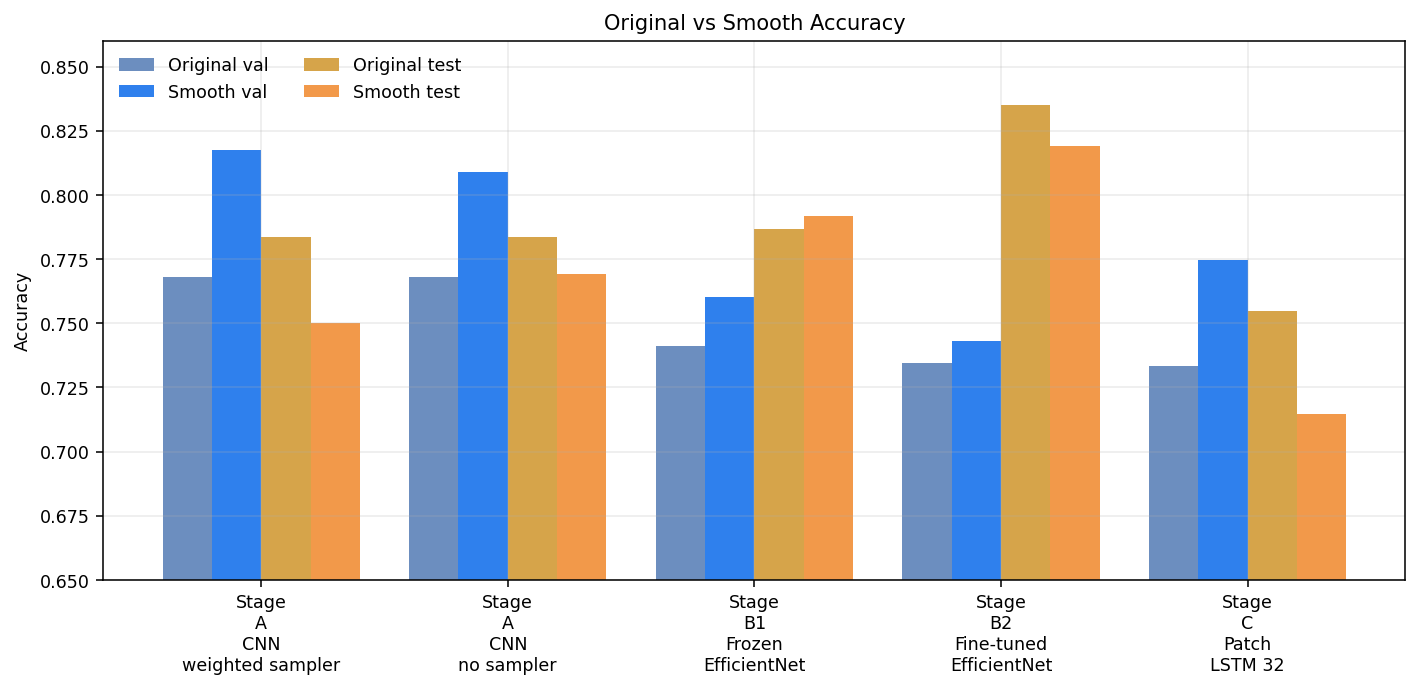

In [2]:
# Rendered from outputs/runs/*/metrics.json


## 5. Validation Smoothness


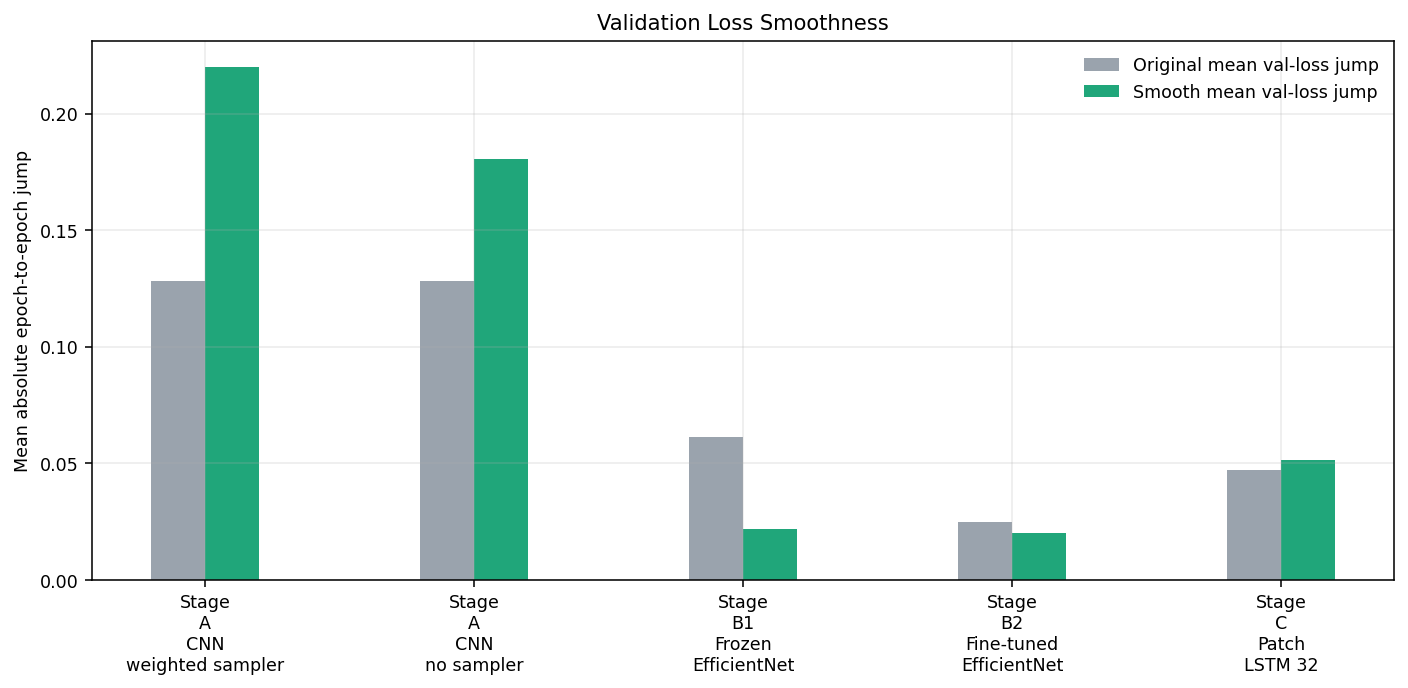

In [3]:
# Rendered from outputs/runs/*/metrics.json


## 6. Validation Loss Curves


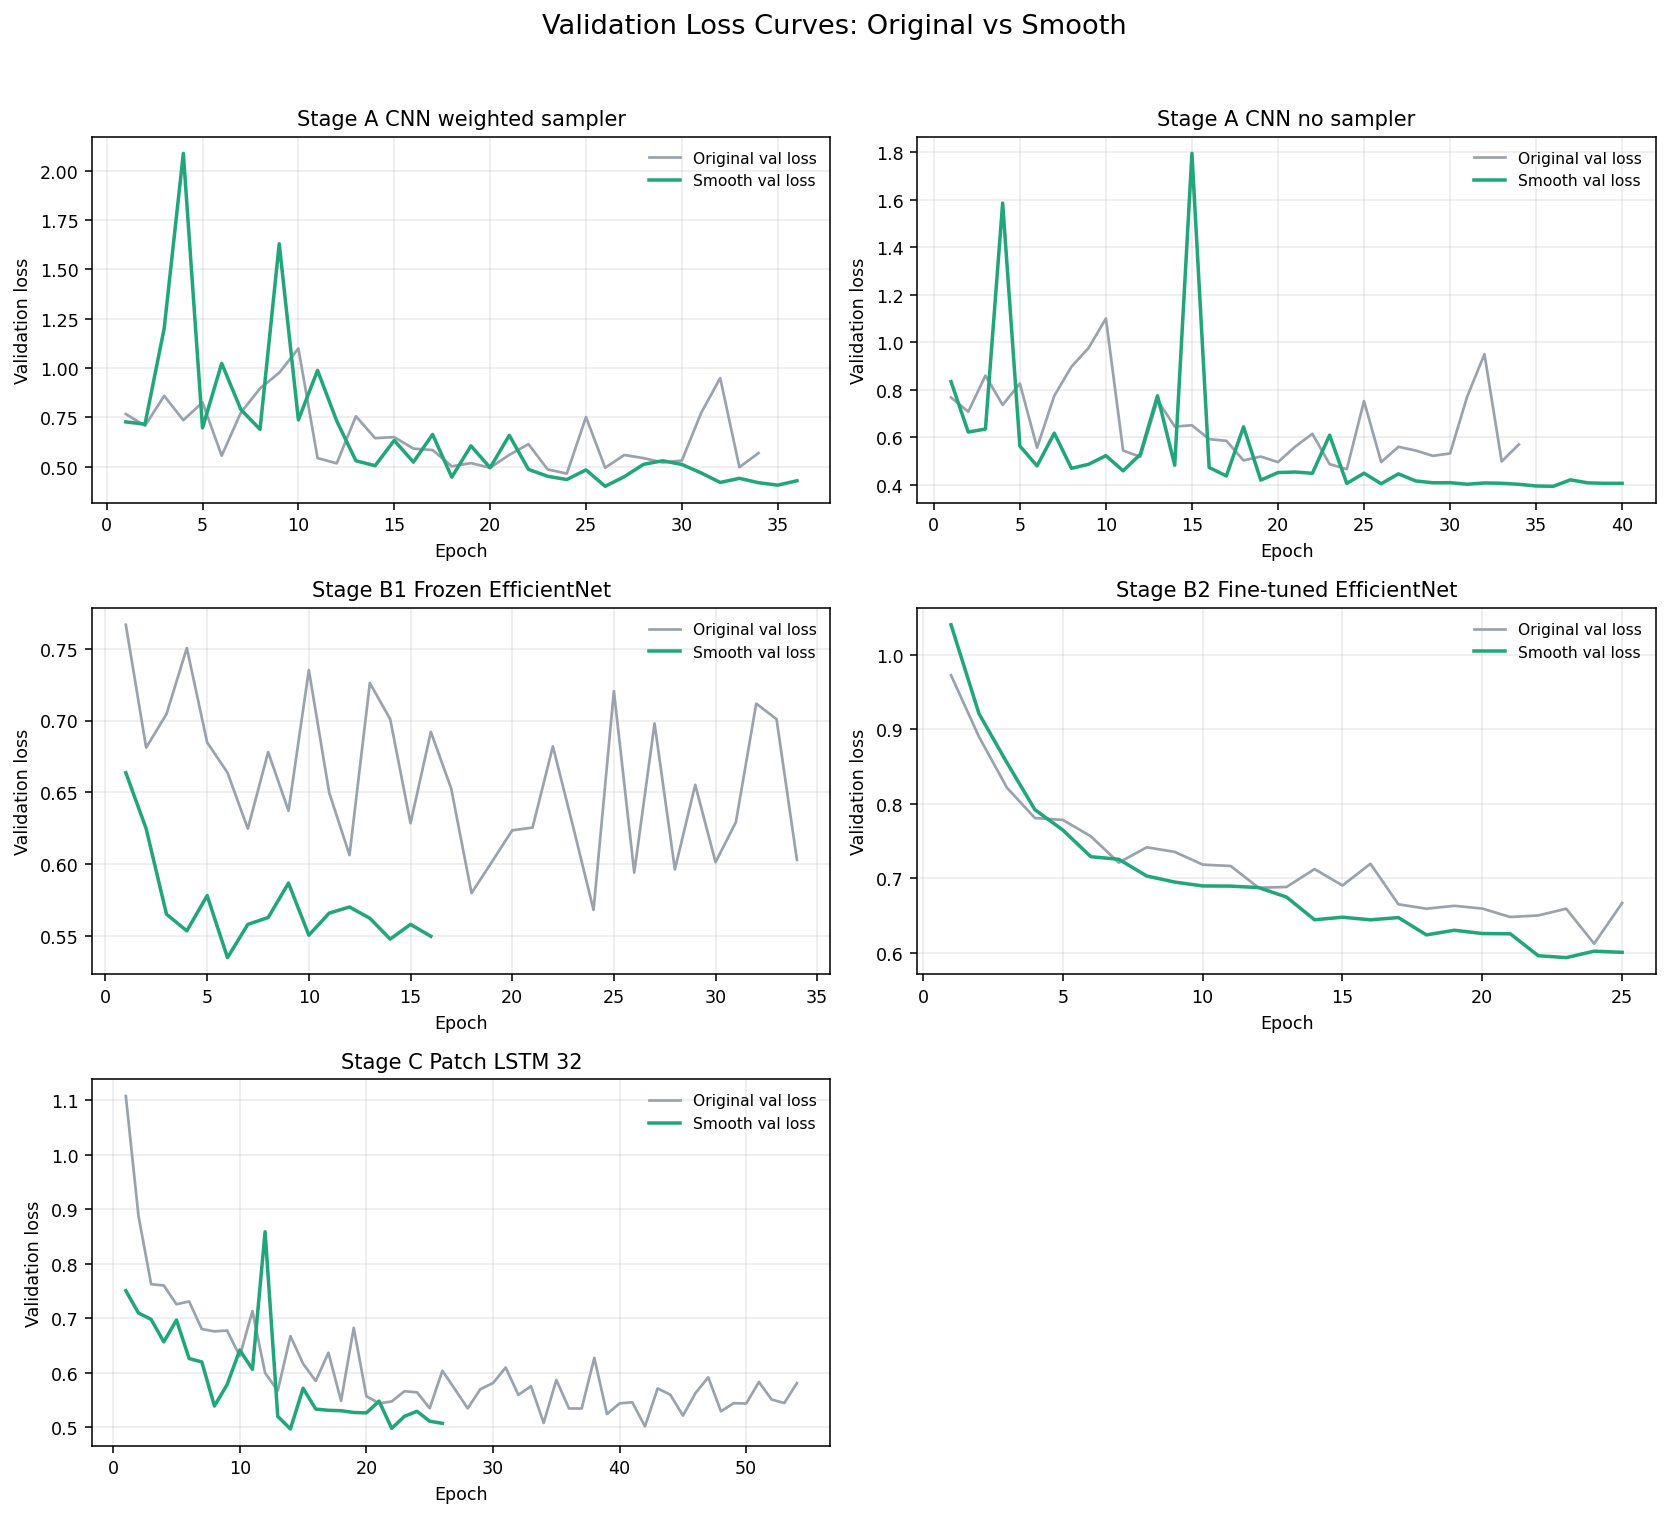

In [4]:
# Rendered from outputs/runs/*/metrics.json


## 7. Interpretation

- The smooth setup clearly helped `b1_frozen_efficientnet_smooth` and `b2_finetuned_efficientnet_smooth` produce steadier validation curves.
- The custom CNN still has early validation-loss spikes. The no-sampler diagnostic shows that weighted sampling was not the only cause, but plain shuffling stabilizes the later CNN epochs.
- `a_custom_cnn_smooth_no_sampler` is the best CNN smooth variant by validation stability and test accuracy.
- The patch-LSTM smooth run improved validation accuracy and shortened training, but test accuracy dropped, so it is less reliable than the EfficientNet runs.
- Best smooth test accuracy is `b2_finetuned_efficientnet_smooth`, but the original fine-tuned EfficientNet still has the best overall test accuracy.
